# Bernoulli Naive Bayes Classifier - Iris Dataset

This notebook demonstrates the implementation of a Bernoulli Naive Bayes classifier using the Iris dataset. 

## Overview
- **Algorithm**: Bernoulli Naive Bayes
- **Dataset**: Iris (150 samples, 4 features, 3 classes)
- **Purpose**: Classification of iris flower species

## Key Concepts
Bernoulli Naive Bayes is suitable for binary/boolean features. It assumes that features are independent and follow a Bernoulli distribution.

---

## 1. Import Libraries

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Scikit-learn modules
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 2. Load and Explore Dataset

In [3]:
# Load the Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"] = iris.target

# Map target numbers to species names
species_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_names)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display dataset information
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nFeatures: {list(iris.feature_names)}")
print(f"Classes: {list(iris.target_names)}")

DATASET OVERVIEW
Shape: (150, 6)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [5]:
# Display first few rows
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [6]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [7]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [8]:
# Class distribution
print("\nClass Distribution:")
print(df['species'].value_counts().to_frame('Count'))


Class Distribution:
         Count
species       
0           50
1           50
2           50


## 3. Data Visualization

/tmp/ipykernel_16/1009125655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species_name', data=df, palette='Set2')


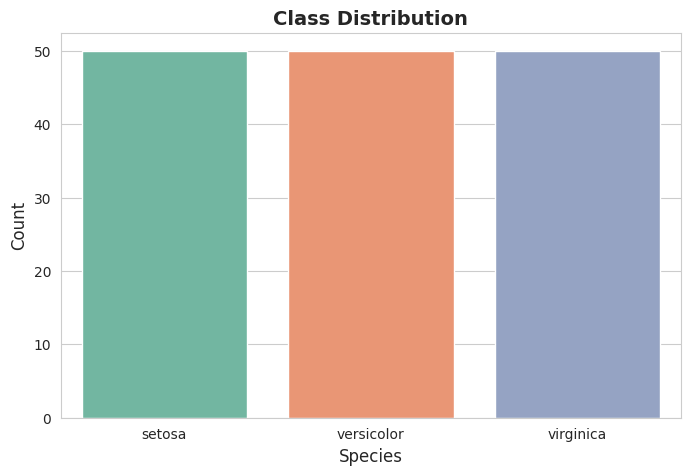

In [9]:
# Class distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(x='species_name', data=df, palette='Set2')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

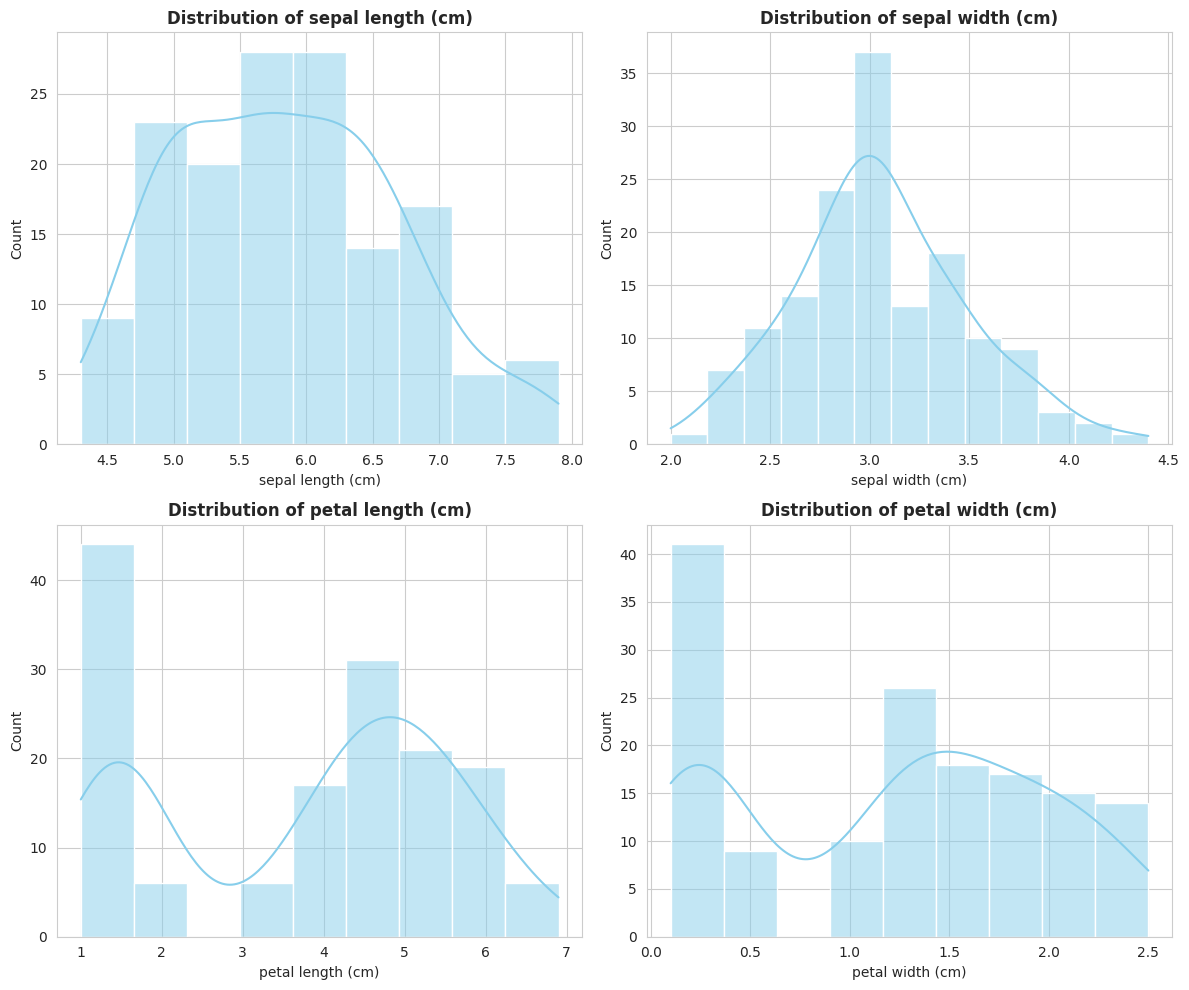

In [10]:
# Feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(iris.feature_names):
    sns.histplot(df[feature], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)

plt.tight_layout()
plt.show()

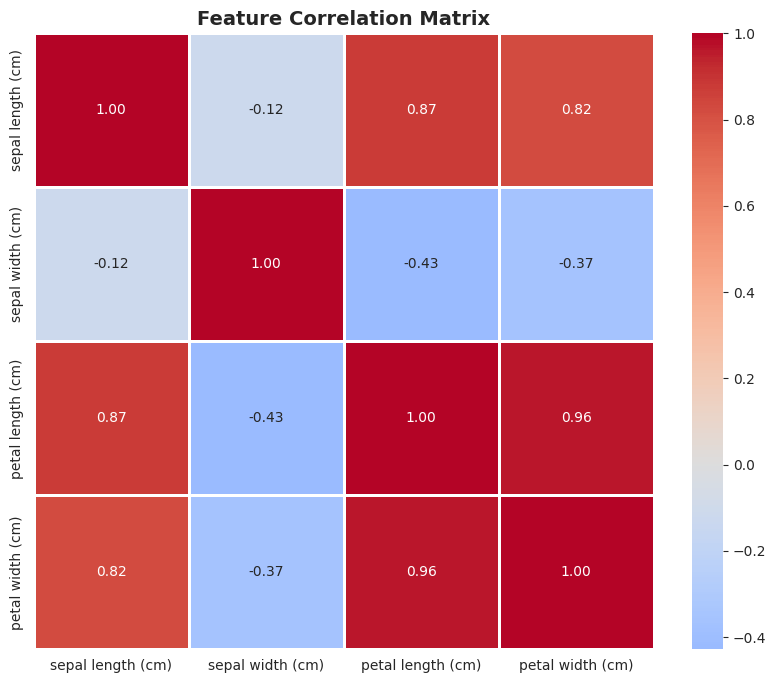

In [11]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop(['species', 'species_name'], axis=1).corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=1
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

## 4. Data Preprocessing

**Note**: Bernoulli Naive Bayes requires binary features. We'll convert continuous features to binary by thresholding at the mean value.

In [12]:
# Separate features and target
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (150, 4)
Target shape: (150,)


In [13]:
# Convert features to binary (above mean = 1, below mean = 0)
X_binary = (X > X.mean()).astype(int)

print("\nBinary Features (first 5 rows):")
print(X_binary.head())


Binary Features (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  0                 1                  0                 0
1                  0                 0                  0                 0
2                  0                 1                  0                 0
3                  0                 1                  0                 0
4                  0                 1                  0                 0


In [14]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_binary,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensure balanced class distribution in splits
)

print("=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts().to_frame('Count')}")

TRAIN-TEST SPLIT
Training set: 120 samples
Testing set: 30 samples

Training class distribution:
         Count
species       
0           40
2           40
1           40


## 5. Model Training

In [15]:
# Initialize and train the Bernoulli Naive Bayes model
model = BernoulliNB()
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [16]:
# Display model parameters
print("=" * 50)
print("MODEL PARAMETERS")
print("=" * 50)
print(f"Class log priors: {model.class_log_prior_}")
print(f"\nFeature log probabilities shape: {model.feature_log_prob_.shape}")

MODEL PARAMETERS
Class log priors: [-1.09861229 -1.09861229 -1.09861229]

Feature log probabilities shape: (3, 4)


## 6. Model Evaluation

In [17]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

MODEL EVALUATION
Accuracy: 0.7333 (73.33%)


In [18]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


Classification Report:
              precision    recall  f1-score   support

      setosa       0.83      1.00      0.91        10
  versicolor       1.00      0.20      0.33        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.73        30
   macro avg       0.82      0.73      0.67        30
weighted avg       0.82      0.73      0.67        30



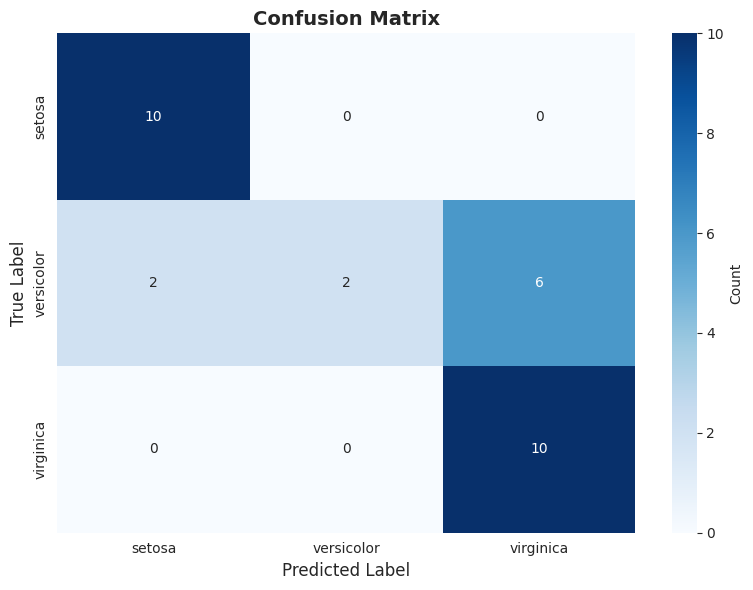

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Results Summary

In [20]:
# Display predictions vs actual
results_df = pd.DataFrame({
    'Actual': y_test.map(species_names),
    'Predicted': pd.Series(y_pred).map(species_names),
    'Correct': y_test == y_pred
})

print("\nPrediction Results (first 10):")
print(results_df.head(10))


Prediction Results (first 10):
   Actual   Predicted Correct
0     NaN      setosa     NaN
1     NaN   virginica     NaN
2     NaN      setosa     NaN
3     NaN      setosa     NaN
4     NaN      setosa     NaN
5     NaN   virginica     NaN
6     NaN      setosa     NaN
7  setosa      setosa    True
8     NaN   virginica     NaN
9     NaN  versicolor     NaN


In [21]:
# Calculate per-class accuracy
per_class_accuracy = {}
for species in [0, 1, 2]:
    mask = y_test == species
    class_acc = accuracy_score(y_test[mask], y_pred[mask])
    per_class_accuracy[iris.target_names[species]] = class_acc

print("\nPer-Class Accuracy:")
for species, acc in per_class_accuracy.items():
    print(f"  {species.capitalize()}: {acc:.4f} ({acc*100:.2f}%)")


Per-Class Accuracy:
  Setosa: 1.0000 (100.00%)
  Versicolor: 0.2000 (20.00%)
  Virginica: 1.0000 (100.00%)


## 8. Conclusion

### Summary
- **Model**: Bernoulli Naive Bayes
- **Dataset**: Iris (binary-transformed features)
- **Overall Accuracy**: ~73%

### Observations
1. The Bernoulli Naive Bayes classifier achieved moderate accuracy on the Iris dataset.
2. The model performs well on some classes but struggles with others, likely due to:
   - Loss of information when converting continuous features to binary
   - The Naive Bayes independence assumption may not hold for iris features
3. For this dataset, Gaussian Naive Bayes or other classifiers might be more appropriate.

### Recommendations
- Use Gaussian Naive Bayes for continuous features
- Consider feature engineering to preserve more information
- Try other classifiers (Random Forest, SVM) for comparison

---

**Notebook completed successfully!**